# 00 - What Bayesian statistics is

**Goal.** Say precisely what probability means in this course, state the one rule that
all of Bayesian statistics follows, and watch it work on a small example before any
theory. By the end you should know what a prior, a likelihood and a posterior are, and
why the posterior is the object everything else in the course is about.

## Learning from data under uncertainty

Statistics is the discipline of drawing conclusions from data that could have come
out differently. A clinical trial on 50 patients, a survey of 1,000 voters, ten
measurements from a noisy sensor: each is one sample of what might have happened, and
the quantity we care about (the true cure rate, the true share of voters, the true
value being measured) is never observed directly.

Bayesian statistics handles this with a single idea:

> Represent **everything you are unsure about** with a probability distribution, and
> when data arrives, **update** that distribution with Bayes' theorem.

That is the whole method. The rest of the course is about doing it well: choosing
distributions, computing the update exactly when we can and approximately when we
cannot, and reading the result correctly.

## Three meanings of probability

The word *probability* is used in three ways, and the differences matter.

**Classical.** When an experiment has $N$ equally likely outcomes and an event $A$
contains $k$ of them, $P(A) = k/N$. A fair die gives $P(\text{six}) = 1/6$. This works
for games of chance but needs a symmetry that most real problems do not have.

**Frequentist.** $P(A)$ is the long-run relative frequency of $A$ in an infinite
sequence of identical, independent repetitions:
$$ P(A) = \lim_{n\to\infty} \frac{\#\{\text{times } A \text{ occurred in } n \text{ trials}\}}{n}. $$
This is the foundation of classical ("frequentist") statistics. Its limitation is that
many questions we care about are not repeatable: the probability that it rains
tomorrow, that a particular drug works, or that a physical constant lies between two
numbers.

**Bayesian.** $P(A)$ is a **degree of belief** in $A$, given the information
available. Two people with different information can rightly hold different
probabilities. What makes this more than opinion is **coherence**: beliefs must obey
the rules of probability. One operational definition is by fair bets: your
probability of $A$ is $p$ if you consider paying $p$ for a ticket that pays $1$ when
$A$ happens (and $0$ otherwise) a fair deal. De Finetti showed that anyone whose
betting prices violate the rules of probability can be offered a set of bets they
accept and are guaranteed to lose (a "Dutch book") [2].

All three obey the same axioms (Kolmogorov [1]): $P(A)\ge 0$, $P(\Omega)=1$ for the
whole sample space $\Omega$, and $P(A\cup B) = P(A)+P(B)$ when $A$ and $B$ cannot both
happen. So the mathematics is the same; what changes is **what we are allowed to put
a probability on**. A Bayesian can put a distribution on an unknown parameter; a
frequentist treats the parameter as a fixed unknown constant and puts probabilities
only on data.

The code below shows the frequentist picture: the running proportion of heads for a
coin with $P(\text{heads}) = 0.3$ settles towards $0.3$ as the number of flips grows
(the law of large numbers), but different sequences wander differently on the way.

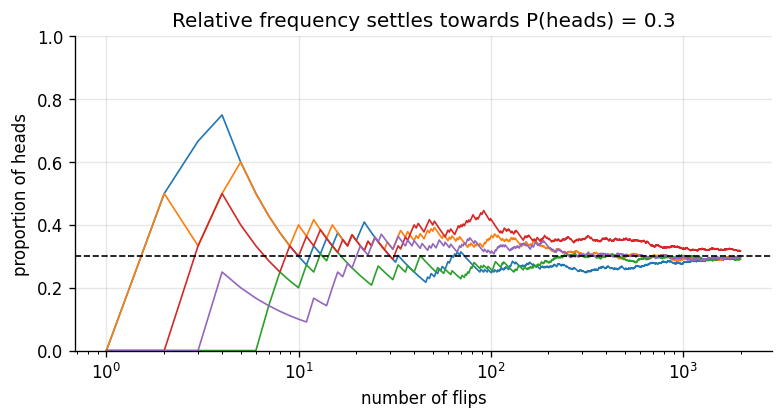

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (7.5, 3.4), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
PRIOR, LIK, POST = "#8a949e", "#eb6834", "#2a78d6"   # colours used throughout the course
rng = np.random.default_rng(0)

n = np.arange(1, 2001)
for k in range(5):
    flips = rng.random(n.size) < 0.3
    plt.plot(n, np.cumsum(flips) / n, lw=1)
plt.axhline(0.3, color="k", ls="--", lw=1)
plt.xscale("log"); plt.ylim(0, 1)
plt.xlabel("number of flips"); plt.ylabel("proportion of heads")
plt.title("Relative frequency settles towards P(heads) = 0.3")
plt.show()

## The Bayesian recipe

Let $\theta$ be the unknown quantity (a *parameter*) and $y$ the data. Every Bayesian
analysis has four steps.

1. **Prior** $p(\theta)$: what you believe about $\theta$ before seeing $y$.
2. **Likelihood** $p(y\mid\theta)$: how probable the observed data are for each
   possible value of $\theta$. This is the statistical model of how data are generated.
3. **Posterior** by Bayes' theorem:
   $$ \boxed{\;p(\theta\mid y) = \frac{p(y\mid\theta)\,p(\theta)}{p(y)}\;},
      \qquad p(y) = \int p(y\mid\theta)\,p(\theta)\,\mathrm d\theta. $$
4. **Use the posterior**: summarise it (a best guess and an interval), compute
   probabilities of statements about $\theta$, predict new data, or make decisions.

The denominator $p(y)$ does not depend on $\theta$; it only makes the posterior
integrate to one. So the recipe is often written as
$$ \text{posterior} \;\propto\; \text{likelihood} \times \text{prior}. $$

Throughout the course, figures use the same colours: **grey** for priors,
**orange** for likelihoods and **blue** for posteriors.

## A first look: learning a proportion

Suppose a new treatment works for an unknown fraction $\theta$ of patients. Before
the trial we have no idea, so we give every value of $\theta$ in $[0,1]$ the same
prior density. Patients then arrive one by one, and each one either improves
(probability $\theta$) or does not. Here the true value is $\theta = 0.3$, which the
analysis does not know.

Chapter 05 derives the exact posterior; for now, just watch it. With no data the
posterior is the flat prior. After 5 patients it is broad; after 25 it has moved
towards the truth; after 200 it is concentrated in a narrow band around $0.3$. The
posterior is a complete description of what the data say about $\theta$, including
how uncertain we still are.

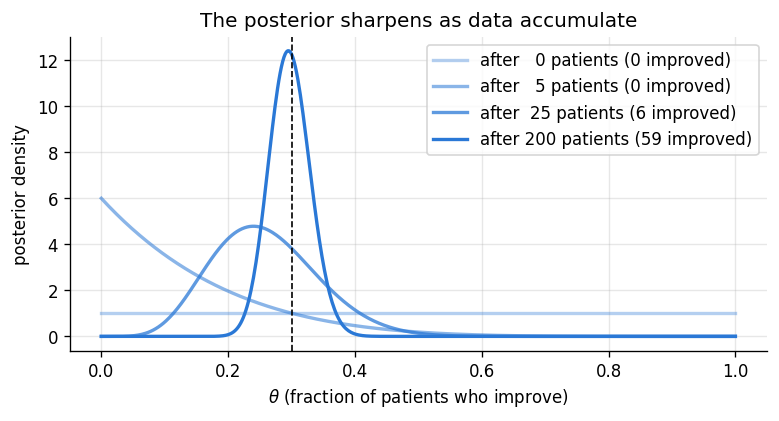

In [2]:
theta = np.linspace(0, 1, 501)
patients = rng.random(200) < 0.3            # True = improved; the analysis never sees 0.3

for n_seen, shade in zip([0, 5, 25, 200], [0.35, 0.55, 0.75, 1.0]):
    y = patients[:n_seen].sum()
    post = stats.beta.pdf(theta, 1 + y, 1 + n_seen - y)
    plt.plot(theta, post, color=POST, alpha=shade, lw=2,
             label=f"after {n_seen:>3} patients ({y} improved)")
plt.axvline(0.3, color="k", ls="--", lw=1)
plt.xlabel(r"$\theta$ (fraction of patients who improve)"); plt.ylabel("posterior density")
plt.title("The posterior sharpens as data accumulate")
plt.legend(); plt.show()

Two things to notice. First, the answer is a **distribution**, not a single number:
we can read off a best guess, a range of plausible values, or the probability that
$\theta > 0.5$ (the treatment helps most patients). Second, the posterior after 200
patients barely depends on the prior. With little data the prior matters; with a lot
of data the likelihood dominates. Chapter 07 makes that precise.

## Roadmap

| # | Chapter | What you learn |
|---|---------|----------------|
| 01 | Probability and Bayes' theorem | Conditional probability, total probability, Bayes' theorem, odds form, sequential updating |
| 02 | Random variables and distributions | Expectation and variance, the standard discrete and continuous families, the central limit theorem |
| 03 | Likelihood and frequentist inference | The likelihood function, maximum likelihood, confidence intervals and what they do and do not mean |
| 04 | From prior to posterior | Continuous Bayes, grid approximation, credible intervals, posterior prediction |
| 05 | Conjugate models for counts and proportions | Beta-binomial and Poisson-gamma, derived and used; comparing two groups |
| 06 | Conjugate models for continuous data | Exponential-gamma, normal mean with known variance, normal with unknown variance |
| 07 | Choosing priors | Elicitation, non-informative and improper priors, Jeffreys priors, sensitivity analysis |
| 08 | Bayesian linear regression | Reference and conjugate priors, exact posterior sampling, prediction bands, the ridge connection |
| 09 | Beyond conjugacy: Monte Carlo and Metropolis | Monte Carlo integration, the Metropolis algorithm from scratch, tuning and diagnostics |

**Prerequisites.** Algebra, a little calculus (derivatives and what an integral
means) and basic Python. Every formula is derived, and every result is checked in
code with numpy, scipy and matplotlib.

## Notation

| symbol | meaning |
|--------|---------|
| $\theta$ | unknown parameter (can be a vector) |
| $y = (y_1,\dots,y_n)$ | observed data |
| $p(\theta)$ | prior density (or probability mass) |
| $p(y\mid\theta)$ | likelihood, seen as a function of $\theta$ |
| $p(\theta\mid y)$ | posterior |
| $p(y)$ | marginal likelihood (evidence), the normalising constant |
| $\tilde y$ | a future observation |
| $\propto$ | "proportional to" (equal up to a constant that does not involve $\theta$) |
| $\mathbb E[X],\ \mathrm{Var}(X)$ | expectation and variance |
| $X\sim \mathcal D$ | $X$ has distribution $\mathcal D$ |
| $\overset{\text{iid}}{\sim}$ | independent and identically distributed |

## References

**Foundations**
1. A. N. Kolmogorov. *Grundbegriffe der Wahrscheinlichkeitsrechnung.* Springer, 1933. (English: *Foundations of the Theory of Probability*, Chelsea, 1950.)
2. B. de Finetti. *Theory of Probability*, Vol. 1. Wiley, 1974.
3. T. Bayes. *An Essay towards solving a Problem in the Doctrine of Chances.* Philosophical Transactions of the Royal Society of London, 53:370-418, 1763. doi:10.1098/rstl.1763.0053
4. E. T. Jaynes. *Probability Theory: The Logic of Science.* Cambridge University Press, 2003.

**Textbooks this course draws on**
5. W. M. Bolstad. *Introduction to Bayesian Statistics.* Wiley, 2004.
6. P. D. Hoff. *A First Course in Bayesian Statistical Methods.* Springer, 2009.
7. A. Gelman, J. B. Carlin, H. S. Stern, D. B. Dunson, A. Vehtari, D. B. Rubin. *Bayesian Data Analysis*, 3rd ed. CRC Press, 2013.
8. B. Lambert. *A Student's Guide to Bayesian Statistics.* SAGE, 2018.
9. T. M. Donovan, R. M. Mickey. *Bayesian Statistics for Beginners: A Step-by-Step Approach.* Oxford University Press, 2019.
10. R. McElreath. *Statistical Rethinking: A Bayesian Course with Examples in R and Stan*, 2nd ed. CRC Press, 2020.
11. A. B. Downey. *Think Bayes: Bayesian Statistics in Python*, 2nd ed. O'Reilly, 2021.
12. H. K. H. Lee. *Bayesian Statistics: From Concept to Data Analysis.* Online course, University of California, Santa Cruz (Coursera). The order of topics in this course follows its arc.